# What Makes a Society Healthy?

## A Machine Learning Analysis of Life Expectancy Across Countries

### Research Question

Which economic, healthcare, lifestyle, environmental and social factors best explain differences in life expectancy across countries?

### Objective

This project investigates the determinants of life expectancy across countries using international datasets and machine learning methods.

The analysis compares different groups of explanatory variables, including economic development, healthcare spending, lifestyle factors, environmental exposure and social indicators.

## Project Framework

The project analyzes life expectancy through five macro-categories of potential determinants:

1. **Economic Factors**
   - GDP per capita

2. **Healthcare Factors**
   - Health expenditure as a percentage of GDP
   - Health expenditure per capita

3. **Lifestyle Factors**
   - Obesity prevalence
   - Smoking prevalence

4. **Environmental Factors**
   - PM2.5 air pollution

5. **Social Factors**
   - Education

The final model selection is based not only on predictive performance, but also on data availability, interpretability and consistency across countries.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)

## Loading Final Project Outputs

The full exploratory workflow is preserved in the working notebook.  
This final notebook focuses on the cleaned outputs, model comparison tables, feature importance results and final visualizations.

In [2]:
model_audit = pd.read_csv("../data/model_audit.csv")
feature_importance_audit = pd.read_csv("../data/feature_importance_audit.csv")
rf_performance_audit = pd.read_csv("../data/random_forest_performance_audit.csv")
final_model_dataset = pd.read_csv("../data/final_absolute_healthcare_environment_model_dataset.csv")

model_audit

,Model_ID,Model_name,Algorithm,Macro_categories,Variables_used,Observations,R_squared,MAE_years,Notes
0,M1,Baseline Linear Regression,Linear Regression,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.447,4.59,Baseline model using economic development and relative healthcare spending.
1,M2,Log-GDP Linear Regression,Linear Regression,"Economic, Relative Healthcare","log_gdp_per_capita, health_expenditure (% of GDP)",191,0.789,2.80,Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita.
2,M3,Baseline Random Forest,Random Forest,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure",191,0.757,2.75,Non-linear baseline model using the same variables as M1.
3,M4,Social Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Social","gdp_per_capita, health_expenditure, education",107,0.630,2.58,Adds education as a social factor; sample size decreases substantially due to missing data.
4,M5,Obesity Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity",177,0.732,2.86,Adds obesity as the first lifestyle variable.
5,M6,Lifestyle Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity, smoking",155,0.802,2.77,Adds obesity and smoking; smoking improves predictive performance.
6,M7,Absolute Healthcare Spending Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle","gdp_per_capita, health_expenditure_per_capita, obesity, smoking",155,0.787,2.79,Replaces health expenditure as % of GDP with health expenditure per capita.
7,M8,Lifestyle & Environment Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure, obesity, smoking, air_pollution",155,0.812,2.70,Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.
8,M9,Absolute Healthcare & Environment Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution",155,0.822,2.59,"Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."


## Model Audit

The following table summarizes all models tested in the project.

The models are organized progressively, starting from simple economic and healthcare baselines and then adding social, lifestyle, environmental and alternative healthcare spending variables.

In [3]:
model_audit

,Model_ID,Model_name,Algorithm,Macro_categories,Variables_used,Observations,R_squared,MAE_years,Notes
0,M1,Baseline Linear Regression,Linear Regression,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure (% of GDP)",191,0.447,4.59,Baseline model using economic development and relative healthcare spending.
1,M2,Log-GDP Linear Regression,Linear Regression,"Economic, Relative Healthcare","log_gdp_per_capita, health_expenditure (% of GDP)",191,0.789,2.80,Tests diminishing returns of income by applying a logarithmic transformation to GDP per capita.
2,M3,Baseline Random Forest,Random Forest,"Economic, Relative Healthcare","gdp_per_capita, health_expenditure",191,0.757,2.75,Non-linear baseline model using the same variables as M1.
3,M4,Social Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Social","gdp_per_capita, health_expenditure, education",107,0.630,2.58,Adds education as a social factor; sample size decreases substantially due to missing data.
4,M5,Obesity Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity",177,0.732,2.86,Adds obesity as the first lifestyle variable.
5,M6,Lifestyle Extension Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle","gdp_per_capita, health_expenditure, obesity, smoking",155,0.802,2.77,Adds obesity and smoking; smoking improves predictive performance.
6,M7,Absolute Healthcare Spending Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle","gdp_per_capita, health_expenditure_per_capita, obesity, smoking",155,0.787,2.79,Replaces health expenditure as % of GDP with health expenditure per capita.
7,M8,Lifestyle & Environment Random Forest,Random Forest,"Economic, Relative Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure, obesity, smoking, air_pollution",155,0.812,2.70,Adds PM2.5 air pollution using 2020 data as the most recent available environmental proxy.
8,M9,Absolute Healthcare & Environment Random Forest,Random Forest,"Economic, Absolute Healthcare, Lifestyle, Environment","gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution",155,0.822,2.59,"Final candidate model combining economic development, absolute healthcare spending, lifestyle factors and air pollution."


## Random Forest Performance Audit

The following table focuses on the Random Forest models only.

These models are compared using:
- R²
- Mean Absolute Error
- Number of observations
- Variables included

In [4]:
rf_performance_audit

,Model_ID,Model_name,Observations,R_squared,MAE_years,Features
0,M3,Baseline Random Forest,191,0.757,2.75,"gdp_per_capita, health_expenditure"
1,M4,Social Extension Random Forest,107,0.630,2.58,"gdp_per_capita, health_expenditure, education"
2,M5,Obesity Extension Random Forest,177,0.732,2.86,"gdp_per_capita, health_expenditure, obesity"
3,M6,Lifestyle Extension Random Forest,155,0.802,2.77,"gdp_per_capita, health_expenditure, obesity, smoking"
4,M7,Absolute Healthcare Spending Random Forest,155,0.787,2.79,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking"
5,M8,Lifestyle & Environment Random Forest,155,0.812,2.70,"gdp_per_capita, health_expenditure, obesity, smoking, air_pollution"
6,M9,Absolute Healthcare & Environment Random Forest,155,0.822,2.59,"gdp_per_capita, health_expenditure_per_capita, obesity, smoking, air_pollution"


## Feature Importance Audit

The feature importance audit compares how the relevance of each variable changes across the Random Forest models.

This helps identify which macro-categories contribute the most to explaining life expectancy.

In [5]:
feature_importance_audit.sort_values(
    by=["Model_ID", "Importance"],
    ascending=[True, False]
)

,Model_ID,Model_name,Feature,Importance
0,M3,Baseline Random Forest,gdp_per_capita,0.832213
1,M3,Baseline Random Forest,health_expenditure,0.167787
2,M4,Social Extension Random Forest,gdp_per_capita,0.661767
3,M4,Social Extension Random Forest,education,0.294693
4,M4,Social Extension Random Forest,health_expenditure,0.043540
5,M5,Obesity Extension Random Forest,gdp_per_capita,0.807329
6,M5,Obesity Extension Random Forest,health_expenditure,0.096621
7,M5,Obesity Extension Random Forest,obesity,0.096050
8,M6,Lifestyle Extension Random Forest,gdp_per_capita,0.784144
9,M6,Lifestyle Extension Random Forest,smoking,0.093903


## Final Visualizations

This section presents the main visual outputs of the project.

The figures summarize:

- the relationship between GDP per capita and life expectancy;
- the effect of the logarithmic GDP transformation;
- model performance across all tested models;
- the feature importance of the final model;
- the comparison between relative and absolute healthcare spending specifications;
- the relationship between air pollution and life expectancy.

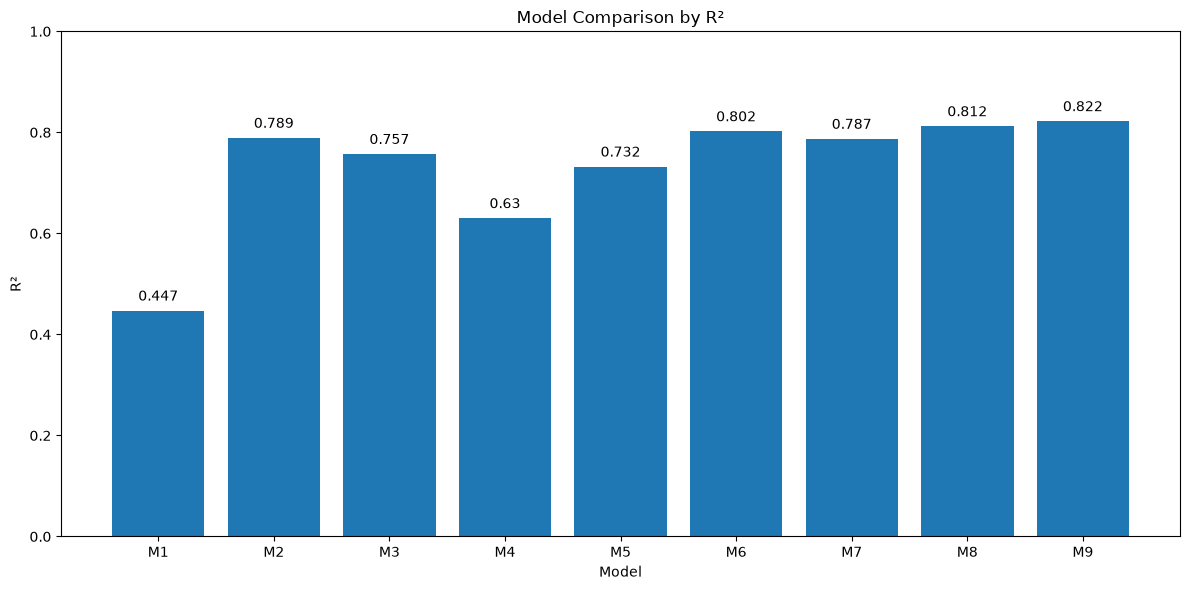

In [6]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_audit["Model_ID"],
    model_audit["R_squared"]
)

plt.title("Model Comparison by R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.ylim(0, 1)

for i, value in enumerate(model_audit["R_squared"]):
    plt.text(i, value + 0.02, str(round(value, 3)), ha="center")

plt.tight_layout()
plt.show()

### Model Comparison by R²

The R² comparison shows how explanatory power changes as additional macro-categories are included in the models.

The strongest model is M9, which combines economic development, absolute healthcare spending, lifestyle variables and air pollution.

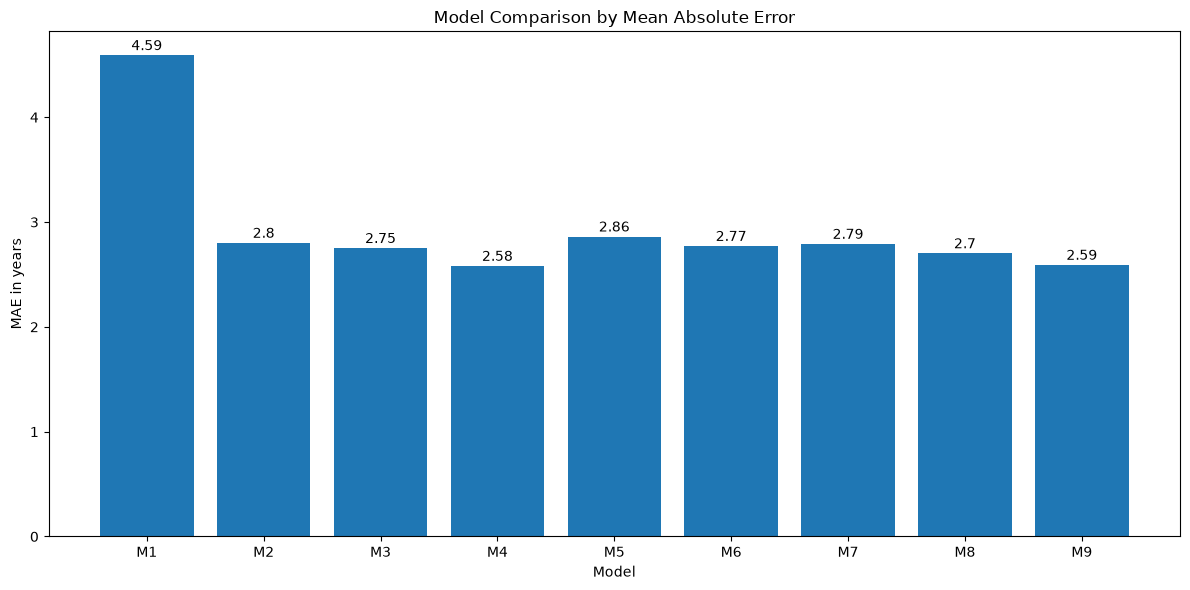

In [7]:
plt.figure(figsize=(12, 6))

plt.bar(
    model_audit["Model_ID"],
    model_audit["MAE_years"]
)

plt.title("Model Comparison by Mean Absolute Error")
plt.xlabel("Model")
plt.ylabel("MAE in years")

for i, value in enumerate(model_audit["MAE_years"]):
    plt.text(i, value + 0.05, str(round(value, 2)), ha="center")

plt.tight_layout()
plt.show()

### Model Comparison by Mean Absolute Error

Mean Absolute Error measures the average prediction error in years.

Although some models achieve low MAE with smaller samples, the final model combines strong predictive performance with a larger and more consistent sample size.

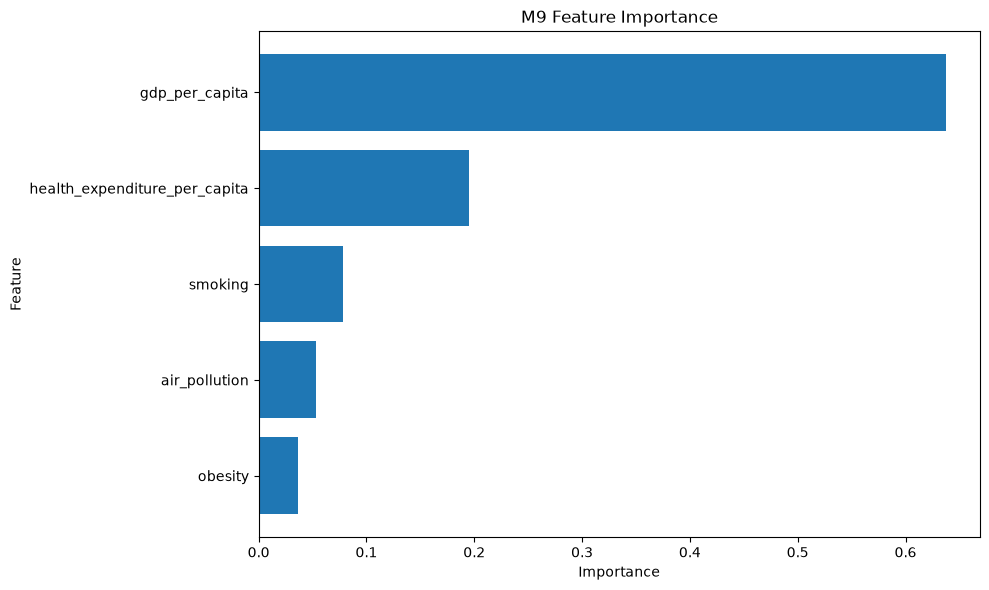

In [8]:
m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"] == "M9"
].sort_values(by="Importance", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(
    m9_importance["Feature"],
    m9_importance["Importance"]
)

plt.title("M9 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Final Model Feature Importance

The feature importance chart for M9 shows which variables contribute most to the final Random Forest model.

GDP per capita remains the dominant predictor, while health expenditure per capita becomes the second most important variable.

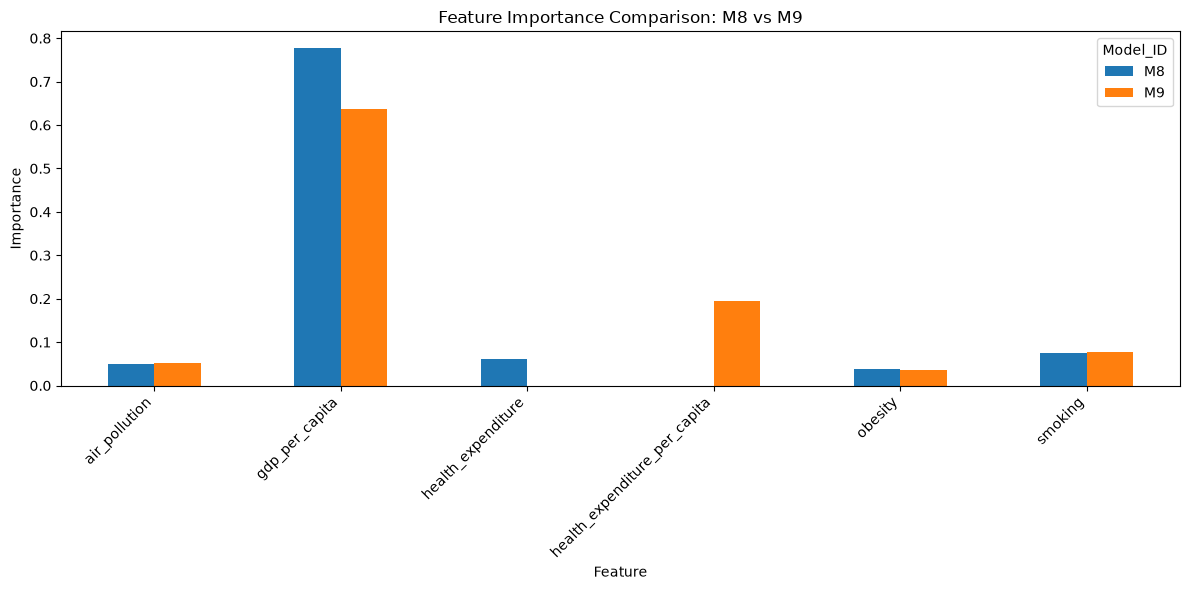

In [9]:
m8_m9_importance = feature_importance_audit[
    feature_importance_audit["Model_ID"].isin(["M8", "M9"])
].copy()

m8_m9_pivot = m8_m9_importance.pivot(
    index="Feature",
    columns="Model_ID",
    values="Importance"
).fillna(0)

m8_m9_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Feature Importance Comparison: M8 vs M9")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Relative vs Absolute Healthcare Spending

M8 uses health expenditure as a percentage of GDP, while M9 uses health expenditure per capita.

This comparison helps evaluate whether relative or absolute healthcare spending is more informative in the final model structure.

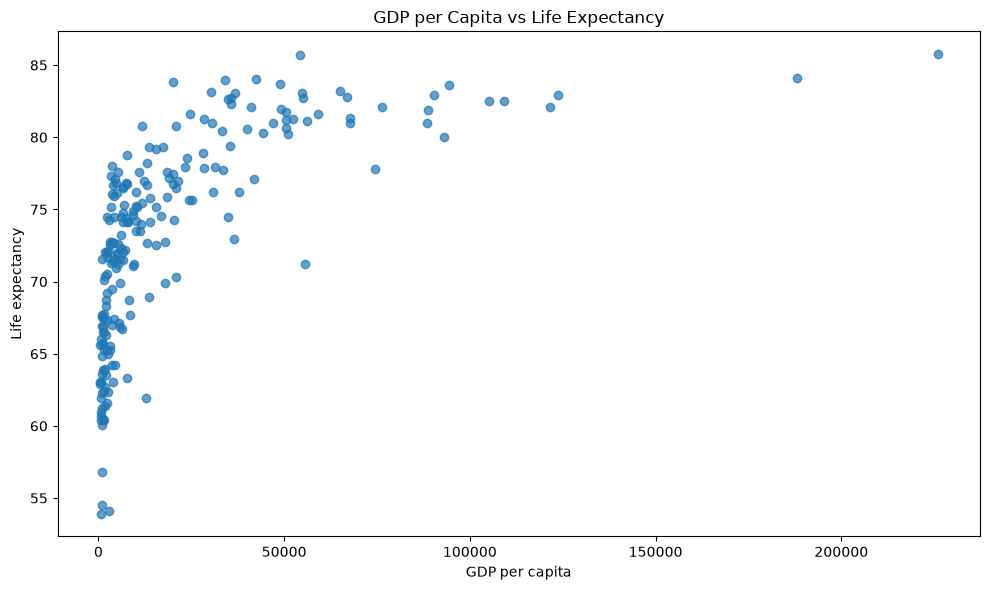

In [10]:
plot_dataset = pd.read_csv("../data/life_expectancy_dataset_v2.csv")

plot_dataset = plot_dataset.dropna(
    subset=["gdp_per_capita", "life_expectancy"]
).copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_dataset["gdp_per_capita"],
    plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("GDP per Capita vs Life Expectancy")
plt.xlabel("GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

### GDP per Capita and Life Expectancy

This scatter plot shows the relationship between economic development and life expectancy.

The relationship appears positive but non-linear, suggesting that additional income may have diminishing returns at higher income levels.

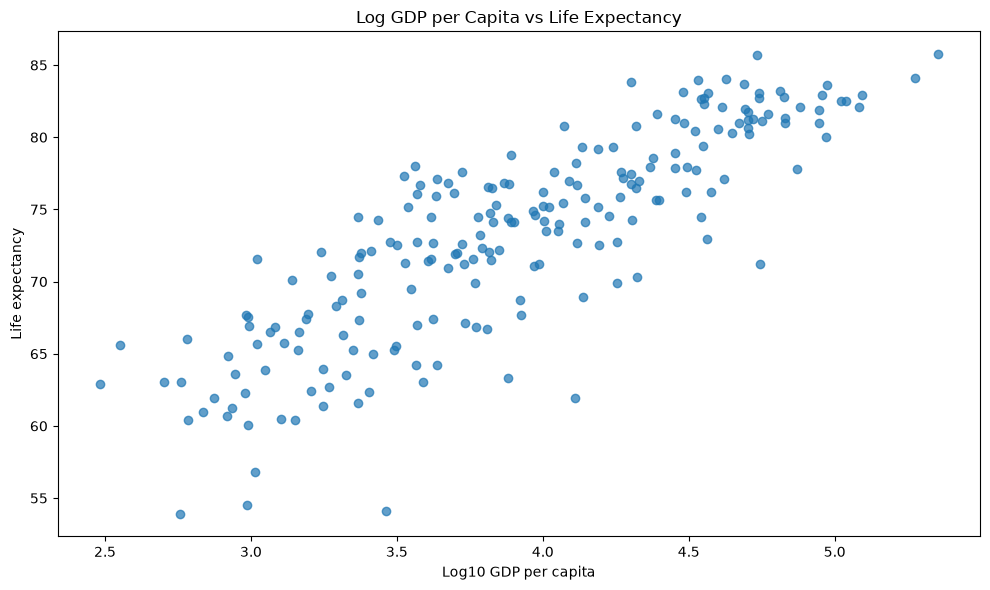

In [11]:
plot_dataset = plot_dataset[
    plot_dataset["gdp_per_capita"] > 0
].copy()

plot_dataset["log_gdp_per_capita"] = np.log10(
    plot_dataset["gdp_per_capita"]
)

plt.figure(figsize=(10, 6))

plt.scatter(
    plot_dataset["log_gdp_per_capita"],
    plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Log GDP per Capita vs Life Expectancy")
plt.xlabel("Log10 GDP per capita")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

### Log GDP per Capita and Life Expectancy

The logarithmic transformation makes the relationship between GDP per capita and life expectancy more linear.

This supports the interpretation that the association between income and life expectancy is stronger at lower income levels and weaker at higher income levels.

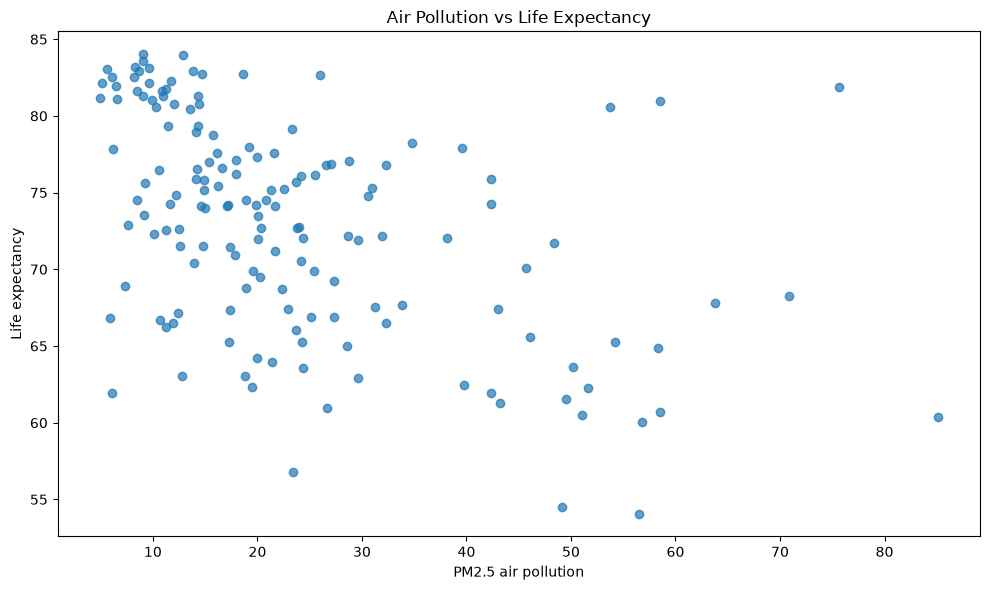

In [13]:
air_pollution_plot_dataset = final_model_dataset.dropna(
    subset=["air_pollution", "life_expectancy"]
).copy()

plt.figure(figsize=(10, 6))

plt.scatter(
    air_pollution_plot_dataset["air_pollution"],
    air_pollution_plot_dataset["life_expectancy"],
    alpha=0.7
)

plt.title("Air Pollution vs Life Expectancy")
plt.xlabel("PM2.5 air pollution")
plt.ylabel("Life expectancy")

plt.tight_layout()
plt.show()

## Final Conclusions

The final conclusions will be completed after reviewing the model audit, feature importance audit and macro-category interpretation.

This section will summarize the main findings on:

- economic factors;
- healthcare factors;
- lifestyle factors;
- environmental factors;
- social factors;
- final model selection;
- limitations of the analysis.